# Tablas y figuras finales de resultados

## Objetivo 

El objetivo de este notebook es consolidar las principales tablas y figuras del proyecto a partir de los resultados generados en los notebooks anteriores.

Hasta ahora se han completado cuatro fases:

1. `01_ingesta_orangebook_drugsfda.ipynb`  
   - lectura de Orange Book y Drugs@FDA;
   - normalización de llaves;
   - construcción del endpoint preliminar;
   - curva Kaplan--Meier global.

2. `02_patentes_exclusividades_endpoint.ipynb`  
   - integración de patentes y exclusividades;
   - curvas Kaplan--Meier por subgrupos regulatorios.

3. `03_modelos_supervivencia_cox_aft.ipynb`  
   - modelos Cox;
   - modelos AFT;
   - comparación de modelos.

4. `04_sensibilidad_cohorte_endpoint.ipynb`  
   - cohortes alternativas;
   - sensibilidad del endpoint;
   - robustez de asociaciones con patentes.

En este quinto notebook se prepararán salidas más limpias para comunicar los resultados.

Las salidas principales serán:

Tablas

- Tabla descriptiva de la cohorte.
- Tabla de variables regulatorias.
- Tabla Kaplan--Meier global y por subgrupos.
- Tabla de modelos Cox principales.
- Tabla de modelos AFT principales.
- Tabla de sensibilidad.

Figuras

- Curva Kaplan--Meier global.
- Curvas Kaplan--Meier por presencia de patente.
- Curvas Kaplan--Meier por tipo de patente.
- Forest plot del modelo Cox principal.
- Sensibilidad de hazard ratios para patentes de sustancia y producto.
- Curvas Kaplan--Meier por cohortes de sensibilidad.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


PROJECT_DIR = Path.cwd()

DATA_INTERMEDIATE_DIR = PROJECT_DIR / "data_intermediate"
DATA_FINAL_DIR = PROJECT_DIR / "data_final"
FIGURES_DIR = PROJECT_DIR / "figures"
TABLES_DIR = PROJECT_DIR / "tables"

SENSITIVITY_DIR = DATA_INTERMEDIATE_DIR / "sensitivity_cohorts"

FINAL_TABLES_DIR = TABLES_DIR / "final"
FINAL_FIGURES_DIR = FIGURES_DIR / "final"

for folder in [
    DATA_INTERMEDIATE_DIR,
    DATA_FINAL_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    FINAL_TABLES_DIR,
    FINAL_FIGURES_DIR
]:
    folder.mkdir(exist_ok=True)


survival_v2_path = DATA_INTERMEDIATE_DIR / "survival_analysis_v2_patents_exclusivities.parquet"
modeling_dataset_path = DATA_INTERMEDIATE_DIR / "survival_modeling_dataset.parquet"

model_comparison_path = TABLES_DIR / "model_comparison_survival.csv"
sensitivity_cohort_summary_path = TABLES_DIR / "sensitivity_cohort_summary.csv"
sensitivity_model_summary_path = TABLES_DIR / "sensitivity_model_summary.csv"

cox_route_adjusted_summary_path = TABLES_DIR / "cox_route_adjusted_summary.csv"
cox_route_stratified_summary_path = TABLES_DIR / "cox_route_stratified_summary.csv"
loglogistic_aft_summary_path = TABLES_DIR / "loglogistic_aft_summary.csv"


survival_v2 = pd.read_parquet(survival_v2_path)
modeling_dataset = pd.read_parquet(modeling_dataset_path)

model_comparison = pd.read_csv(model_comparison_path)
sensitivity_cohort_summary = pd.read_csv(sensitivity_cohort_summary_path)
sensitivity_model_summary = pd.read_csv(sensitivity_model_summary_path)

cox_route_adjusted_summary = pd.read_csv(cox_route_adjusted_summary_path)
cox_route_stratified_summary = pd.read_csv(cox_route_stratified_summary_path)
loglogistic_aft_summary = pd.read_csv(loglogistic_aft_summary_path)

print("=" * 80)
print("Archivos cargados correctamente")
print("=" * 80)

print(f"survival_v2: {survival_v2.shape[0]:,} filas | {survival_v2.shape[1]:,} columnas")
print(f"modeling_dataset: {modeling_dataset.shape[0]:,} filas | {modeling_dataset.shape[1]:,} columnas")

print("\nTablas cargadas:")
print(f"- model_comparison: {model_comparison.shape}")
print(f"- sensitivity_cohort_summary: {sensitivity_cohort_summary.shape}")
print(f"- sensitivity_model_summary: {sensitivity_model_summary.shape}")
print(f"- cox_route_adjusted_summary: {cox_route_adjusted_summary.shape}")
print(f"- cox_route_stratified_summary: {cox_route_stratified_summary.shape}")
print(f"- loglogistic_aft_summary: {loglogistic_aft_summary.shape}")

print("\nCarpetas de salida final:")
print(f"- {FINAL_TABLES_DIR}")
print(f"- {FINAL_FIGURES_DIR}")

print("\nColumnas principales de survival_v2:")
print(list(survival_v2.columns))

Archivos cargados correctamente
survival_v2: 1,439 filas | 46 columnas
modeling_dataset: 1,439 filas | 11 columnas

Tablas cargadas:
- model_comparison: (6, 8)
- sensitivity_cohort_summary: (5, 14)
- sensitivity_model_summary: (25, 13)
- cox_route_adjusted_summary: (13, 12)
- cox_route_stratified_summary: (5, 12)
- loglogistic_aft_summary: (15, 13)

Carpetas de salida final:
- /Users/juanalbertomartinez/Desktop/Patente/tables/final
- /Users/juanalbertomartinez/Desktop/Patente/figures/final

Columnas principales de survival_v2:
['ingredient', 'dosage_form', 'route', 'nme_approval_date', 'approval_year', 'innovator_appl_no', 'innovator_product_no', 'innovator_trade_name', 'first_generic_approval_date', 'first_generic_appl_no', 'first_generic_product_no', 'first_generic_trade_name', 'first_generic_te_code', 'event', 'end_date', 'time_to_generic_years', 'n_nda_products', 'n_nda_applications', 'n_anda_products_total', 'n_anda_applications_total', 'ingredient_key', 'dosage_form_key', 'route_



Los archivos necesarios para construir las tablas y figuras finales se cargaron correctamente.

La base principal `survival_v2` contiene 1,439 unidades y 46 columnas. Esta base incluye el endpoint de supervivencia, variables regulatorias de patentes y exclusividades, así como variables de producto.

También se cargó `modeling_dataset`, con 1,439 unidades y 11 columnas, que corresponde a la base usada para ajustar los modelos de supervivencia.

Las tablas de resultados están disponibles y tienen las dimensiones esperadas:

- `model_comparison`: comparación de 6 modelos.
- `sensitivity_cohort_summary`: resumen de 5 cohortes de sensibilidad.
- `sensitivity_model_summary`: resultados de modelos en cohortes de sensibilidad.
- `cox_route_adjusted_summary`: modelo Cox ajustado por ruta.
- `cox_route_stratified_summary`: modelo Cox estratificado por ruta.
- `loglogistic_aft_summary`: modelo AFT Log-Logistic.

También se crearon las carpetas finales:

```text
tables/final/
figures/final/

## Tabla descriptiva final de la cohorte

En esta sección construiremos una tabla descriptiva compacta de la cohorte principal.

La tabla incluirá:

- número total de unidades;
- número de eventos;
- número de censuras;
- proporción de eventos;
- años de aprobación mínimo y máximo;
- mediana del tiempo observado;
- mediana del tiempo a genérico entre eventos;
- mediana Kaplan--Meier;
- número de unidades con patentes;
- número de unidades con exclusividades.

Esta tabla servirá como resumen inicial de la base analítica usada en los modelos.

In [3]:
# Tabla descriptiva final de la cohorte

from lifelines import KaplanMeierFitter

def km_median_time(df, duration_col="time_to_generic_years", event_col="event"):
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=df[duration_col],
        event_observed=df[event_col]
    )
    return kmf.median_survival_time_

n_units = len(survival_v2)
n_events = int(survival_v2["event"].sum())
n_censored = int((survival_v2["event"] == 0).sum())

cohort_descriptive = pd.DataFrame({
    "Metric": [
        "Units",
        "Observed generic entries",
        "Censored units",
        "Event rate",
        "Approval year range",
        "Median observed time, years",
        "Median time among events, years",
        "Kaplan--Meier median time, years",
        "Units with any listed patent",
        "Units with drug substance patent",
        "Units with drug product patent",
        "Units with listed exclusivity"
    ],
    "Value": [
        f"{n_units:,}",
        f"{n_events:,}",
        f"{n_censored:,}",
        f"{100 * n_events / n_units:.1f}%",
        f"{int(survival_v2['approval_year'].min())}--{int(survival_v2['approval_year'].max())}",
        f"{survival_v2['time_to_generic_years'].median():.2f}",
        f"{survival_v2.loc[survival_v2['event'].eq(1), 'time_to_generic_years'].median():.2f}",
        f"{km_median_time(survival_v2):.2f}",
        f"{int(survival_v2['has_patent'].sum()):,} ({100 * survival_v2['has_patent'].mean():.1f}%)",
        f"{int(survival_v2['has_drug_substance_patent'].sum()):,} ({100 * survival_v2['has_drug_substance_patent'].mean():.1f}%)",
        f"{int(survival_v2['has_drug_product_patent'].sum()):,} ({100 * survival_v2['has_drug_product_patent'].mean():.1f}%)",
        f"{int(survival_v2['has_exclusivity'].sum()):,} ({100 * survival_v2['has_exclusivity'].mean():.1f}%)"
    ]
})

display(cohort_descriptive)


cohort_descriptive_path = FINAL_TABLES_DIR / "table_01_cohort_descriptive.csv"
cohort_descriptive.to_csv(cohort_descriptive_path, index=False)

print(f"Tabla guardada en: {cohort_descriptive_path}")

,Metric,Value
0,Units,"1,439"
1,Observed generic entries,859
2,Censored units,580
3,Event rate,59.7%
4,Approval year range,1998--2018
5,"Median observed time, years",10.31
6,"Median time among events, years",8.37
7,"Kaplan--Meier median time, years",12.79
8,Units with any listed patent,589 (40.9%)
9,Units with drug substance patent,264 (18.3%)


Tabla guardada en: /Users/juanalbertomartinez/Desktop/Patente/tables/final/table_01_cohort_descriptive.csv


La cohorte principal contiene 1,439 unidades ingrediente--forma--ruta aprobadas entre 1998 y 2018. De estas unidades, 859 tuvieron entrada observada de un genérico comparable y 580 quedaron censuradas, lo que corresponde a una tasa de evento de 59.7%.

La mediana simple del tiempo observado fue de 10.31 años, mientras que la mediana entre los eventos observados fue de 8.37 años. Al considerar adecuadamente la censura mediante Kaplan--Meier, la mediana estimada del tiempo hasta genérico fue de 12.79 años.

En términos regulatorios, 40.9% de las unidades tuvo al menos una patente listada, 18.3% tuvo patente de sustancia, 35.0% tuvo patente de producto y 10.4% tuvo alguna exclusividad listada.

Esta tabla resume de manera compacta la población analítica usada en los modelos principales.


## Tabla final de variables regulatorias

En esta sección construiremos una tabla descriptiva enfocada en variables regulatorias.

La tabla resumirá:

- presencia de cualquier patente;
- presencia de patente de sustancia;
- presencia de patente de producto;
- presencia de código de uso;
- presencia de exclusividad;
- número de patentes;
- número de exclusividades;
- años hasta expiración máxima de patente;
- años hasta expiración máxima de exclusividad.

Esta tabla complementa la descripción general de la cohorte y permite documentar la distribución de las variables explicativas principales.

In [5]:
# Tabla final de variables regulatorias

reg_binary_vars = {
    "Any listed patent": "has_patent",
    "Drug substance patent": "has_drug_substance_patent",
    "Drug product patent": "has_drug_product_patent",
    "Patent use code": "has_patent_use_code",
    "Listed exclusivity": "has_exclusivity",
    "NCE-like exclusivity": "has_nce_like_exclusivity",
    "Orphan-like exclusivity": "has_orphan_like_exclusivity",
    "Pediatric-like exclusivity": "has_pediatric_like_exclusivity",
}

binary_rows = []

for label, col in reg_binary_vars.items():
    n_true = int(survival_v2[col].sum())
    binary_rows.append({
        "Variable": label,
        "Type": "Binary",
        "Summary": f"{n_true:,} ({100 * n_true / len(survival_v2):.1f}%)"
    })

reg_numeric_vars = {
    "Number of patents": "n_patents",
    "Number of exclusivities": "n_exclusivities",
    "Years to maximum patent expiry": "years_to_patent_expiry_max",
    "Years to maximum exclusivity expiry": "years_to_exclusivity_expiry_max",
}

numeric_rows = []

for label, col in reg_numeric_vars.items():
    x = survival_v2[col].dropna()
    numeric_rows.append({
        "Variable": label,
        "Type": "Numeric",
        "Summary": f"median {x.median():.2f}; IQR {x.quantile(0.25):.2f}--{x.quantile(0.75):.2f}; n={len(x):,}"
    })

regulatory_descriptive = pd.DataFrame(binary_rows + numeric_rows)

display(regulatory_descriptive)

# Guardar tabla
regulatory_descriptive_path = FINAL_TABLES_DIR / "table_02_regulatory_descriptive.csv"
regulatory_descriptive.to_csv(regulatory_descriptive_path, index=False)

print(f"Tabla guardada en: {regulatory_descriptive_path}")

,Variable,Type,Summary
0,Any listed patent,Binary,589 (40.9%)
1,Drug substance patent,Binary,264 (18.3%)
2,Drug product patent,Binary,504 (35.0%)
3,Patent use code,Binary,473 (32.9%)
4,Listed exclusivity,Binary,150 (10.4%)
5,NCE-like exclusivity,Binary,9 (0.6%)
6,Orphan-like exclusivity,Binary,68 (4.7%)
7,Pediatric-like exclusivity,Binary,51 (3.5%)
8,Number of patents,Numeric,"median 0.00; IQR 0.00--3.00; n=1,439"
9,Number of exclusivities,Numeric,"median 0.00; IQR 0.00--0.00; n=1,439"


Tabla guardada en: /Users/juanalbertomartinez/Desktop/Patente/tables/final/table_02_regulatory_descriptive.csv


La tabla muestra que 40.9% de las unidades tiene al menos una patente listada. Las patentes de producto son más frecuentes que las patentes de sustancia:

- patente de producto: 35.0%;
- patente de sustancia: 18.3%.

También se observa que 32.9% de las unidades tiene al menos un código de uso de patente.

Las exclusividades listadas aparecen en 10.4% de la cohorte. Dentro de las categorías exploratorias, las exclusividades tipo huérfana u ODE son las más frecuentes, con 4.7%, seguidas por las pediátricas con 3.5%. Las exclusividades tipo NCE aparecen en una proporción baja, 0.6%, dentro de esta cohorte preliminar.

En cuanto a las variables numéricas, la mediana del número de patentes es 0 porque la mayoría de las unidades no tiene patente listada. Entre las unidades con patente, la mediana del tiempo desde aprobación hasta la expiración máxima de patente es de aproximadamente 18.65 años. Entre las unidades con exclusividad, la mediana del tiempo hasta expiración máxima de exclusividad es de aproximadamente 13.34 años.

Esta tabla será útil para describir la disponibilidad y distribución de las variables regulatorias incluidas en los modelos.

## Curva Kaplan--Meier global final

En esta sección se generará una versión final de la curva Kaplan--Meier global.

La curva representa la probabilidad estimada de permanecer sin genérico comparable después de cierto número de años desde la aprobación del innovador candidato.

Además de la figura, se generará una tabla con la supervivencia estimada a:

- 5 años;
- 10 años;
- 15 años;
- 20 años.

Esta figura y tabla pueden usarse directamente en un reporte o manuscrito.

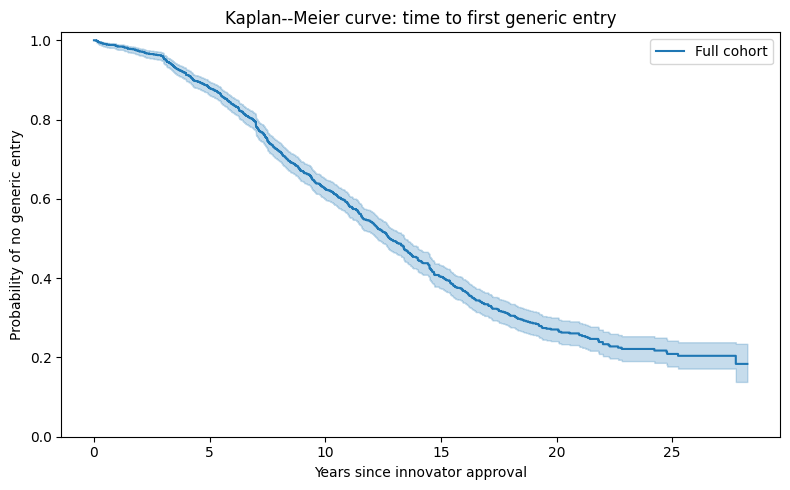

Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/final/figure_01_km_global.png


,time_years,survival_probability,cumulative_probability_generic_entry,km_median_time
0,5,0.879083,0.120917,12.791239
1,10,0.626227,0.373773,12.791239
2,15,0.404237,0.595763,12.791239
3,20,0.270477,0.729523,12.791239


Tabla guardada en: /Users/juanalbertomartinez/Desktop/Patente/tables/final/table_03_km_global_summary.csv


In [7]:
# Curva Kaplan--Meier global final

kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_v2["time_to_generic_years"],
    event_observed=survival_v2["event"],
    label="Full cohort"
)

fig, ax = plt.subplots(figsize=(8, 5))

kmf.plot_survival_function(ax=ax, ci_show=True)

ax.set_xlabel("Years since innovator approval")
ax.set_ylabel("Probability of no generic entry")
ax.set_title("Kaplan--Meier curve: time to first generic entry")
ax.set_ylim(0, 1.02)

plt.tight_layout()

km_global_path = FINAL_FIGURES_DIR / "figure_01_km_global.png"
plt.savefig(km_global_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {km_global_path}")

# Tabla de supervivencia en tiempos seleccionados
times_to_report = [5, 10, 15, 20]

km_global_summary = pd.DataFrame({
    "time_years": times_to_report,
    "survival_probability": [
        float(kmf.survival_function_at_times(t).iloc[0])
        for t in times_to_report
    ]
})

km_global_summary["cumulative_probability_generic_entry"] = (
    1 - km_global_summary["survival_probability"]
)

km_global_summary["km_median_time"] = kmf.median_survival_time_

display(km_global_summary)

km_global_summary_path = FINAL_TABLES_DIR / "table_03_km_global_summary.csv"
km_global_summary.to_csv(km_global_summary_path, index=False)

print(f"Tabla guardada en: {km_global_summary_path}")

La curva muestra la probabilidad estimada de que una unidad permanezca sin entrada genérica comparable conforme pasan los años desde la aprobación del innovador.

Los valores puntuales son:

- a 5 años, la probabilidad de no tener genérico es aproximadamente 87.9%, por lo que la probabilidad acumulada de entrada genérica es 12.1%;
- a 10 años, la probabilidad de no tener genérico baja a 62.6%, con probabilidad acumulada de entrada genérica de 37.4%;
- a 15 años, la probabilidad de no tener genérico es 40.4%, por lo que la probabilidad acumulada de entrada genérica alcanza 59.6%;
- a 20 años, la probabilidad de no tener genérico es 27.0%, con probabilidad acumulada de entrada genérica de 73.0%.

La mediana Kaplan--Meier del tiempo hasta primera entrada genérica es de 12.79 años. Esto significa que, bajo la estimación de supervivencia, alrededor de la mitad de las unidades habría tenido entrada genérica comparable aproximadamente 12.8 años después de la aprobación del innovador.


## Curvas Kaplan--Meier por presencia de patente

En esta sección se comparará el tiempo hasta entrada genérica entre unidades con y sin patentes listadas.

Se generarán curvas Kaplan--Meier para:

- unidades sin patente listada;
- unidades con al menos una patente listada.

Además, se calculará una tabla con:

- tamaño de grupo;
- número de eventos;
- tasa de eventos;
- mediana Kaplan--Meier;
- prueba log-rank entre grupos.

Esta comparación resume la asociación descriptiva entre patentes y entrada genérica.

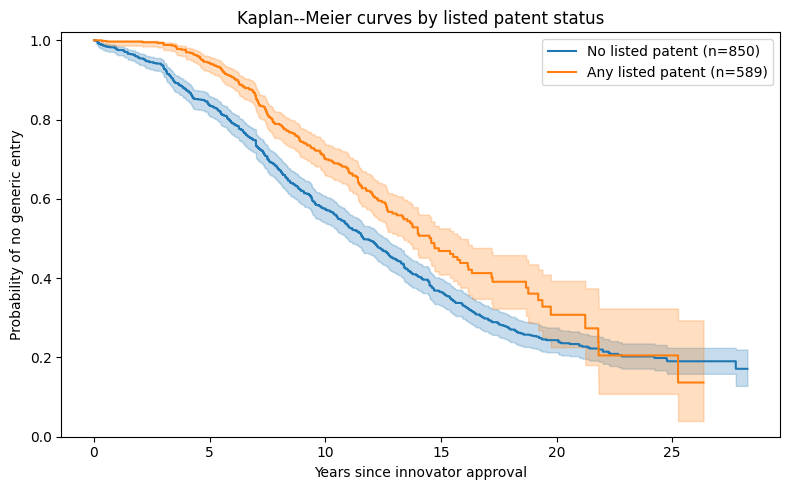

Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/final/figure_02_km_by_any_patent.png


,group_variable,group,n_units,n_events,event_rate,km_median_time,group_label,logrank_p
0,has_patent,False,850,618,0.727059,11.646817,No listed patent,0.000001
1,has_patent,True,589,241,0.409168,14.576318,Any listed patent,0.000001


Tabla guardada en: /Users/juanalbertomartinez/Desktop/Patente/tables/final/table_04_km_by_any_patent.csv


In [8]:
# Curvas Kaplan--Meier por presencia de patente

from lifelines.statistics import logrank_test

def km_group_summary_binary(df, group_col, duration_col="time_to_generic_years", event_col="event"):
    """
    Resume curvas KM para una variable binaria.
    """
    rows = []
    
    for value, group_df in df.groupby(group_col):
        kmf_tmp = KaplanMeierFitter()
        kmf_tmp.fit(
            durations=group_df[duration_col],
            event_observed=group_df[event_col]
        )
        
        rows.append({
            "group_variable": group_col,
            "group": value,
            "n_units": len(group_df),
            "n_events": int(group_df[event_col].sum()),
            "event_rate": group_df[event_col].mean(),
            "km_median_time": kmf_tmp.median_survival_time_
        })
    
    return pd.DataFrame(rows)


# Asegurar variable booleana
survival_v2["has_patent"] = survival_v2["has_patent"].fillna(False).astype(bool)

# Figura
fig, ax = plt.subplots(figsize=(8, 5))

label_map = {
    False: "No listed patent",
    True: "Any listed patent"
}

for value, group_df in survival_v2.groupby("has_patent"):
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=group_df["time_to_generic_years"],
        event_observed=group_df["event"],
        label=f"{label_map[value]} (n={len(group_df)})"
    )
    kmf.plot_survival_function(ax=ax, ci_show=True)

ax.set_xlabel("Years since innovator approval")
ax.set_ylabel("Probability of no generic entry")
ax.set_title("Kaplan--Meier curves by listed patent status")
ax.set_ylim(0, 1.02)

plt.tight_layout()

km_patent_path = FINAL_FIGURES_DIR / "figure_02_km_by_any_patent.png"
plt.savefig(km_patent_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {km_patent_path}")

# Tabla KM por grupo
km_patent_summary = km_group_summary_binary(survival_v2, "has_patent")
km_patent_summary["group_label"] = km_patent_summary["group"].map(label_map)

# Log-rank test
df_no_patent = survival_v2.loc[survival_v2["has_patent"].eq(False)]
df_patent = survival_v2.loc[survival_v2["has_patent"].eq(True)]

logrank_patent = logrank_test(
    df_no_patent["time_to_generic_years"],
    df_patent["time_to_generic_years"],
    event_observed_A=df_no_patent["event"],
    event_observed_B=df_patent["event"]
)

km_patent_summary["logrank_p"] = logrank_patent.p_value

display(km_patent_summary)

km_patent_summary_path = FINAL_TABLES_DIR / "table_04_km_by_any_patent.csv"
km_patent_summary.to_csv(km_patent_summary_path, index=False)

print(f"Tabla guardada en: {km_patent_summary_path}")

La comparación muestra una separación clara entre unidades con y sin patente listada.

Las unidades sin patente listada tienen:

- 850 unidades;
- 618 eventos;
- tasa de evento de 72.7%;
- mediana Kaplan--Meier de 11.65 años.

Las unidades con al menos una patente listada tienen:

- 589 unidades;
- 241 eventos;
- tasa de evento de 40.9%;
- mediana Kaplan--Meier de 14.58 años.

La prueba log-rank arroja un valor p muy pequeño, aproximadamente p<0.001, lo que indica una diferencia estadísticamente clara entre las curvas.

En términos descriptivos, las unidades con patente listada permanecen más tiempo sin entrada genérica comparable. Esta diferencia es coherente con los modelos Cox y AFT ajustados en notebooks anteriores, donde las variables de patente se asociaron con entrada genérica más tardía.


## Curvas Kaplan--Meier por tipo de patente

En esta sección se generarán curvas Kaplan--Meier para dos tipos específicos de patente:

- patente de sustancia;
- patente de producto.

Para cada tipo de patente se compararán unidades con y sin ese atributo.

También se generará una tabla resumen con:

- tamaño de grupo;
- número de eventos;
- tasa de evento;
- mediana Kaplan--Meier;
- valor \(p\) de la prueba log-rank.

Estas comparaciones permiten distinguir qué tipo de patente muestra una separación más clara en el tiempo hasta entrada genérica.

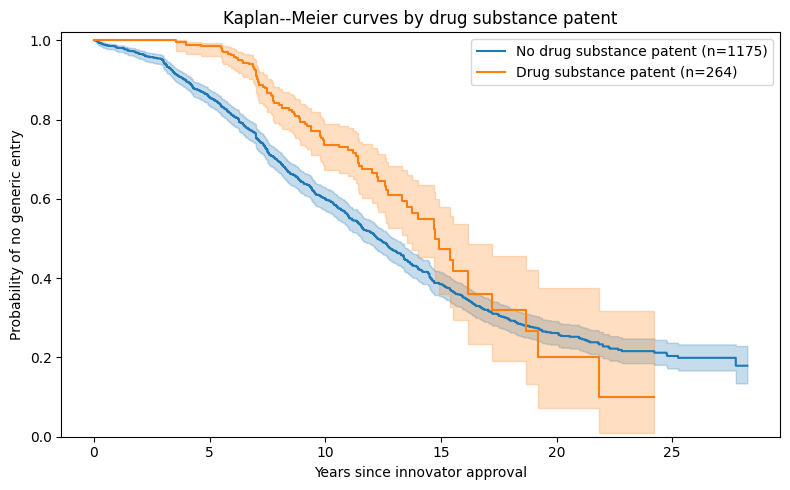

Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/final/figure_03a_km_by_drug_substance_patent.png


,group_variable,group,n_units,n_events,event_rate,km_median_time,group_label,logrank_p
0,has_drug_substance_patent,False,1175,769,0.654468,12.246407,No drug substance patent,0.000032
1,has_drug_substance_patent,True,264,90,0.340909,14.724162,Drug substance patent,0.000032


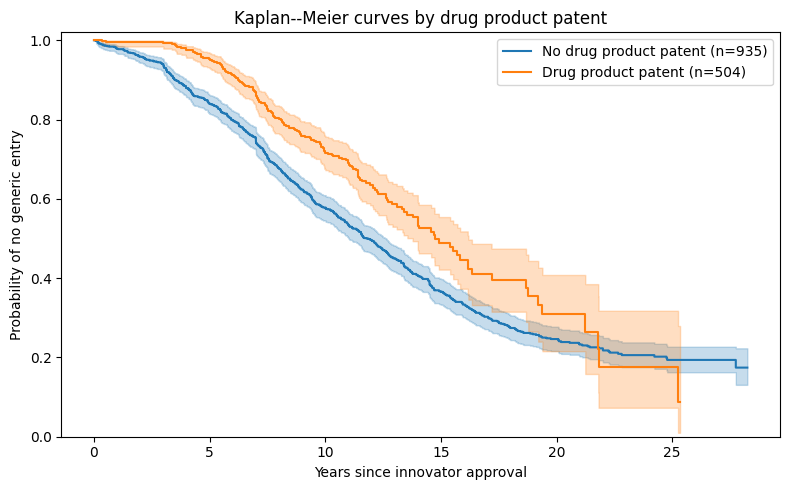

Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/final/figure_03b_km_by_drug_product_patent.png


,group_variable,group,n_units,n_events,event_rate,km_median_time,group_label,logrank_p
0,has_drug_product_patent,False,935,667,0.713369,11.783710,No drug product patent,5.023677e-07
1,has_drug_product_patent,True,504,192,0.380952,14.724162,Drug product patent,5.023677e-07


Tabla guardada en: /Users/juanalbertomartinez/Desktop/Patente/tables/final/table_05_km_by_patent_type.csv


In [9]:
# Curvas Kaplan--Meier por tipo de patente


patent_type_vars = {
    "has_drug_substance_patent": {
        "title": "Kaplan--Meier curves by drug substance patent",
        "filename": "figure_03a_km_by_drug_substance_patent.png",
        "label_true": "Drug substance patent",
        "label_false": "No drug substance patent"
    },
    "has_drug_product_patent": {
        "title": "Kaplan--Meier curves by drug product patent",
        "filename": "figure_03b_km_by_drug_product_patent.png",
        "label_true": "Drug product patent",
        "label_false": "No drug product patent"
    }
}

km_patent_type_summaries = []

for group_col, info in patent_type_vars.items():
    survival_v2[group_col] = survival_v2[group_col].fillna(False).astype(bool)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    label_map = {
        False: info["label_false"],
        True: info["label_true"]
    }
    
    for value, group_df in survival_v2.groupby(group_col):
        kmf = KaplanMeierFitter()
        kmf.fit(
            durations=group_df["time_to_generic_years"],
            event_observed=group_df["event"],
            label=f"{label_map[value]} (n={len(group_df)})"
        )
        kmf.plot_survival_function(ax=ax, ci_show=True)
    
    ax.set_xlabel("Years since innovator approval")
    ax.set_ylabel("Probability of no generic entry")
    ax.set_title(info["title"])
    ax.set_ylim(0, 1.02)
    
    plt.tight_layout()
    
    fig_path = FINAL_FIGURES_DIR / info["filename"]
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Figura guardada en: {fig_path}")
    
    # Tabla resumen
    tmp_summary = km_group_summary_binary(survival_v2, group_col)
    tmp_summary["group_label"] = tmp_summary["group"].map(label_map)
    
    df_false = survival_v2.loc[survival_v2[group_col].eq(False)]
    df_true = survival_v2.loc[survival_v2[group_col].eq(True)]
    
    logrank_tmp = logrank_test(
        df_false["time_to_generic_years"],
        df_true["time_to_generic_years"],
        event_observed_A=df_false["event"],
        event_observed_B=df_true["event"]
    )
    
    tmp_summary["logrank_p"] = logrank_tmp.p_value
    km_patent_type_summaries.append(tmp_summary)
    
    display(tmp_summary)

km_patent_type_summary = pd.concat(km_patent_type_summaries, ignore_index=True)

km_patent_type_summary_path = FINAL_TABLES_DIR / "table_05_km_by_patent_type.csv"
km_patent_type_summary.to_csv(km_patent_type_summary_path, index=False)

print(f"Tabla guardada en: {km_patent_type_summary_path}")

Para las patentes de sustancia, se observa una separación clara entre los grupos. Las unidades sin patente de sustancia tienen una mediana Kaplan--Meier de aproximadamente 12.25 años, mientras que las unidades con patente de sustancia tienen una mediana de aproximadamente 14.72 años. La tasa de evento también es menor en el grupo con patente de sustancia: 34.1% frente a 65.4%. La prueba log-rank indica una diferencia estadísticamente clara entre las curvas.

Para las patentes de producto se observa un patrón similar. Las unidades sin patente de producto tienen una mediana Kaplan--Meier de aproximadamente 11.78 años, mientras que las unidades con patente de producto tienen una mediana de aproximadamente 14.72 años. La tasa de evento es menor en el grupo con patente de producto: 38.1% frente a 71.3%. La prueba log-rank también muestra una diferencia clara entre curvas.

En conjunto, las curvas descriptivas sugieren que tanto las patentes de sustancia como las patentes de producto se asocian con una entrada genérica más tardía. Sin embargo, como vimos en los modelos ajustados, la señal de patente de sustancia es la más robusta frente a distintas especificaciones y análisis de sensibilidad.


## Tabla final del modelo Cox principal

En esta sección construiremos una tabla limpia del modelo Cox estratificado por ruta.

Este modelo se considera una especificación principal de interpretación porque:

- ajusta por año de aprobación;
- incluye los tipos principales de patente;
- incluye exclusividad;
- estratifica por ruta para reducir problemas asociados al supuesto de riesgos proporcionales.

La tabla final incluirá:

- variable;
- hazard ratio;
- intervalo de confianza del 95%;
- valor $p$;
- interpretación resumida.

Un hazard ratio menor que 1 indica menor hazard de entrada genérica, es decir, entrada genérica más tardía.

In [10]:
# Tabla final del modelo Cox principal

cox_final = cox_route_stratified_summary.copy()

# Revisar nombres de columnas
print("Columnas disponibles en cox_route_stratified_summary:")
print(list(cox_final.columns))

# Estandarizar columnas principales
cox_final_table = cox_final.rename(columns={
    "covariate": "variable",
    "exp(coef)": "HR",
    "exp(coef) lower 95%": "HR_lower_95",
    "exp(coef) upper 95%": "HR_upper_95"
}).copy()

# En algunos archivos la columna de variable puede venir como index o Unnamed
if "variable" not in cox_final_table.columns:
    possible_var_cols = [c for c in cox_final_table.columns if "Unnamed" in c or c == "index"]
    if possible_var_cols:
        cox_final_table = cox_final_table.rename(columns={possible_var_cols[0]: "variable"})

# Etiquetas legibles
variable_labels = {
    "approval_year_centered": "Approval year, centered",
    "has_drug_substance_patent": "Drug substance patent",
    "has_drug_product_patent": "Drug product patent",
    "has_patent_use_code": "Patent use code",
    "has_exclusivity": "Listed exclusivity"
}

cox_final_table["Variable"] = cox_final_table["variable"].map(variable_labels).fillna(cox_final_table["variable"])

# Interpretación breve
def interpret_hr(hr):
    if pd.isna(hr):
        return ""
    if hr < 1:
        return "Lower hazard of generic entry"
    elif hr > 1:
        return "Higher hazard of generic entry"
    else:
        return "No difference"

cox_final_table["Interpretation"] = cox_final_table["HR"].apply(interpret_hr)

# Formato
cox_final_table_clean = cox_final_table[[
    "Variable",
    "HR",
    "HR_lower_95",
    "HR_upper_95",
    "p",
    "Interpretation"
]].copy()

cox_final_table_clean["HR"] = cox_final_table_clean["HR"].round(3)
cox_final_table_clean["HR_lower_95"] = cox_final_table_clean["HR_lower_95"].round(3)
cox_final_table_clean["HR_upper_95"] = cox_final_table_clean["HR_upper_95"].round(3)
cox_final_table_clean["p"] = cox_final_table_clean["p"].map(lambda x: f"{x:.3g}")

display(cox_final_table_clean)

# Guardar tabla
cox_final_table_path = FINAL_TABLES_DIR / "table_06_cox_stratified_main_model.csv"
cox_final_table_clean.to_csv(cox_final_table_path, index=False)

print(f"Tabla guardada en: {cox_final_table_path}")

Columnas disponibles en cox_route_stratified_summary:
['variable', 'coef', 'exp(coef)', 'se(coef)', 'coef lower 95%', 'coef upper 95%', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'cmp to', 'z', 'p', '-log2(p)']


,Variable,HR,HR_lower_95,HR_upper_95,p,Interpretation
0,"Approval year, centered",1.008,0.993,1.023,0.291,Higher hazard of generic entry
1,Drug substance patent,0.628,0.472,0.837,0.00148,Lower hazard of generic entry
2,Drug product patent,0.734,0.575,0.939,0.0138,Lower hazard of generic entry
3,Patent use code,1.018,0.807,1.284,0.882,Higher hazard of generic entry
4,Listed exclusivity,0.996,0.750,1.322,0.976,Lower hazard of generic entry


Tabla guardada en: /Users/juanalbertomartinez/Desktop/Patente/tables/final/table_06_cox_stratified_main_model.csv


El modelo muestra que, después de ajustar por año de aprobación y estratificar por ruta, las variables de patente son las que concentran la señal principal.

La patente de sustancia tiene un hazard ratio de aproximadamente 0.628, con intervalo de confianza 95% de 0.472 a 0.837 y $p$=0.00148. Esto indica una menor tasa instantánea de entrada genérica, es decir, una entrada más tardía de genéricos en unidades con patente de sustancia.

La patente de producto también muestra un hazard ratio menor que 1, aproximadamente 0.734, con intervalo de confianza 95% de 0.575 a 0.939 y p=0.0138. Esto sugiere una asociación con entrada genérica más tardía, aunque en los análisis de sensibilidad esta señal fue menos estable que la patente de sustancia.

El código de uso de patente tiene un hazard ratio cercano a 1 y no es estadísticamente significativo. La exclusividad listada también tiene un hazard ratio prácticamente igual a 1 y no muestra evidencia de asociación en esta especificación.

El año de aprobación centrado tampoco muestra una asociación clara en este modelo estratificado.


## Forest plot del modelo Cox principal

En esta sección construiremos una figura tipo forest plot para el modelo Cox estratificado por ruta.

La figura mostrará:

- hazard ratio estimado;
- intervalo de confianza del 95%;
- línea vertical en $HR=1$.

Esta visualización facilita interpretar cuáles variables se asocian con entrada genérica más temprana o más tardía.

Un hazard ratio menor que 1 indica menor hazard de entrada genérica, es decir, entrada más tardía.

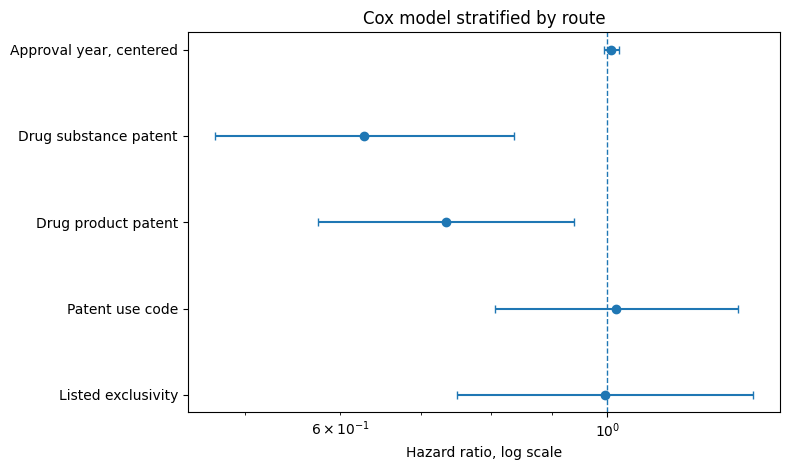

Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/final/figure_04_cox_stratified_forest_plot.png


,label,hr,hr_lower,hr_upper,p
4,Listed exclusivity,0.995667,0.749856,1.322059,0.976054
3,Patent use code,1.017755,0.806636,1.284128,0.882051
2,Drug product patent,0.734466,0.574564,0.938870,0.013759
1,Drug substance patent,0.628427,0.471896,0.836880,0.001481
0,"Approval year, centered",1.008084,0.993129,1.023264,0.291027


In [11]:
# Forest plot del modelo Cox principal

forest_df = cox_final_table.copy()

# Mantener solo variables principales del modelo
forest_df = forest_df.loc[
    forest_df["variable"].isin([
        "approval_year_centered",
        "has_drug_substance_patent",
        "has_drug_product_patent",
        "has_patent_use_code",
        "has_exclusivity"
    ])
].copy()

forest_df["label"] = forest_df["variable"].map(variable_labels)

forest_df = forest_df.rename(columns={
    "HR": "hr",
    "HR_lower_95": "hr_lower",
    "HR_upper_95": "hr_upper"
})

# Orden para mostrar
order = [
    "Listed exclusivity",
    "Patent use code",
    "Drug product patent",
    "Drug substance patent",
    "Approval year, centered"
]

forest_df["label"] = pd.Categorical(
    forest_df["label"],
    categories=order,
    ordered=True
)

forest_df = forest_df.sort_values("label")

fig, ax = plt.subplots(figsize=(8, 4.8))

y_pos = np.arange(len(forest_df))

ax.errorbar(
    forest_df["hr"],
    y_pos,
    xerr=[
        forest_df["hr"] - forest_df["hr_lower"],
        forest_df["hr_upper"] - forest_df["hr"]
    ],
    fmt="o",
    capsize=3
)

ax.axvline(1, linestyle="--", linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(forest_df["label"].astype(str))
ax.set_xscale("log")
ax.set_xlabel("Hazard ratio, log scale")
ax.set_title("Cox model stratified by route")

plt.tight_layout()

cox_forest_path = FINAL_FIGURES_DIR / "figure_04_cox_stratified_forest_plot.png"
plt.savefig(cox_forest_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {cox_forest_path}")

display(
    forest_df[[
        "label", "hr", "hr_lower", "hr_upper", "p"
    ]]
)

La figura resume visualmente los hazard ratios del modelo principal.

Las dos variables que aparecen claramente por debajo de la línea $HR=1$ son:

* patente de sustancia;
* patente de producto.

Esto indica que ambas se asocian con menor hazard de entrada genérica, es decir, con entrada genérica más tardía.

La patente de sustancia muestra la asociación más fuerte y precisa, con $HR \approx 0.63$ e intervalo de confianza completamente por debajo de 1. La patente de producto también está por debajo de 1, con $HR \approx 0.73$, aunque su efecto es menos marcado.

En cambio, el código de uso de patente y la exclusividad listada tienen intervalos de confianza que cruzan claramente la línea $HR=1$, por lo que no muestran una asociación clara en este modelo.

El año de aprobación centrado tiene un hazard ratio muy cercano a 1, lo que sugiere que, una vez estratificado por ruta y ajustado por las variables regulatorias, no hay una asociación temporal fuerte en esta especificación.



## Tabla final del modelo AFT Log-Logistic

En esta sección construiremos una tabla limpia del modelo AFT Log-Logistic.

Este modelo fue el mejor entre los modelos AFT comparados y ofrece una interpretación complementaria al modelo Cox.

En un modelo AFT, los coeficientes exponenciados se interpretan como factores multiplicativos del tiempo:

- un valor mayor que 1 indica mayor tiempo hasta entrada genérica;
- un valor menor que 1 indica menor tiempo hasta entrada genérica.

La tabla final incluirá:

- variable;
- factor de tiempo;
- intervalo de confianza del 95%;
- valor \(p\);
- interpretación resumida.

In [12]:
# Tabla final del modelo AFT Log-Logistic

aft_final = loglogistic_aft_summary.copy()

print("Columnas disponibles en loglogistic_aft_summary:")
print(list(aft_final.columns))

# En lifelines AFT, normalmente aparecen columnas como:
# param, covariate, coef, exp(coef), exp(coef) lower 95%, exp(coef) upper 95%, p

# Filtrar solo el parámetro principal alpha_, si existe
if "param" in aft_final.columns:
    aft_final = aft_final.loc[aft_final["param"].eq("alpha_")].copy()

# Estandarizar nombres
aft_final_table = aft_final.rename(columns={
    "covariate": "variable",
    "exp(coef)": "time_ratio",
    "exp(coef) lower 95%": "time_ratio_lower_95",
    "exp(coef) upper 95%": "time_ratio_upper_95"
}).copy()

# Si la variable viene con otro nombre
if "variable" not in aft_final_table.columns:
    possible_var_cols = [c for c in aft_final_table.columns if "Unnamed" in c or c == "index"]
    if possible_var_cols:
        aft_final_table = aft_final_table.rename(columns={possible_var_cols[0]: "variable"})

# Etiquetas legibles
aft_variable_labels = {
    "approval_year_centered": "Approval year, centered",
    "has_drug_substance_patent": "Drug substance patent",
    "has_drug_product_patent": "Drug product patent",
    "has_patent_use_code": "Patent use code",
    "has_exclusivity": "Listed exclusivity",
    "route_simplified_INJECTION": "Route: injection",
    "route_simplified_INTRAVENOUS": "Route: intravenous",
    "route_simplified_OPHTHALMIC": "Route: ophthalmic",
    "route_simplified_ORAL": "Route: oral",
    "route_simplified_OTHER": "Route: other",
    "route_simplified_SUBCUTANEOUS": "Route: subcutaneous",
    "route_simplified_TOPICAL": "Route: topical",
    "route_simplified_TRANSDERMAL": "Route: transdermal",
    "Intercept": "Intercept"
}

aft_final_table["Variable"] = aft_final_table["variable"].map(aft_variable_labels).fillna(aft_final_table["variable"])

def interpret_time_ratio(tr):
    if pd.isna(tr):
        return ""
    if tr > 1:
        return "Longer time to generic entry"
    elif tr < 1:
        return "Shorter time to generic entry"
    else:
        return "No difference"

aft_final_table["Interpretation"] = aft_final_table["time_ratio"].apply(interpret_time_ratio)

# Mantener variables principales y rutas
aft_final_table_clean = aft_final_table[[
    "Variable",
    "time_ratio",
    "time_ratio_lower_95",
    "time_ratio_upper_95",
    "p",
    "Interpretation"
]].copy()

aft_final_table_clean["time_ratio"] = aft_final_table_clean["time_ratio"].round(3)
aft_final_table_clean["time_ratio_lower_95"] = aft_final_table_clean["time_ratio_lower_95"].round(3)
aft_final_table_clean["time_ratio_upper_95"] = aft_final_table_clean["time_ratio_upper_95"].round(3)
aft_final_table_clean["p"] = aft_final_table_clean["p"].map(lambda x: f"{x:.3g}")

display(aft_final_table_clean)

# Guardar tabla
aft_final_table_path = FINAL_TABLES_DIR / "table_07_loglogistic_aft_main_model.csv"
aft_final_table_clean.to_csv(aft_final_table_path, index=False)

print(f"Tabla guardada en: {aft_final_table_path}")

Columnas disponibles en loglogistic_aft_summary:
['param', 'variable', 'coef', 'exp(coef)', 'se(coef)', 'coef lower 95%', 'coef upper 95%', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'cmp to', 'z', 'p', '-log2(p)']


,Variable,time_ratio,time_ratio_lower_95,time_ratio_upper_95,p,Interpretation
0,"Approval year, centered",0.992,0.983,1.001,0.0874,Shorter time to generic entry
1,Drug product patent,1.227,1.053,1.431,0.00889,Longer time to generic entry
2,Drug substance patent,1.356,1.147,1.604,0.000371,Longer time to generic entry
3,Listed exclusivity,1.097,0.926,1.300,0.283,Longer time to generic entry
4,Patent use code,1.036,0.894,1.200,0.642,Longer time to generic entry
5,Route: injection,0.679,0.462,0.997,0.0481,Shorter time to generic entry
6,Route: intravenous,0.522,0.376,0.727,0.000115,Shorter time to generic entry
7,Route: ophthalmic,0.548,0.375,0.802,0.00198,Shorter time to generic entry
8,Route: oral,0.373,0.275,0.505,1.9e-10,Shorter time to generic entry
9,Route: other,0.684,0.486,0.960,0.0283,Shorter time to generic entry


Tabla guardada en: /Users/juanalbertomartinez/Desktop/Patente/tables/final/table_07_loglogistic_aft_main_model.csv



Este modelo ofrece una lectura complementaria al modelo Cox. En lugar de interpretar hazard ratios, el modelo AFT usa factores multiplicativos del tiempo.

Las dos variables de patente muestran factores de tiempo mayores que 1:

* patente de producto: factor de tiempo (\approx 1.23);
* patente de sustancia: factor de tiempo (\approx 1.36).

Esto significa que, bajo el modelo AFT, las unidades con patente de producto o patente de sustancia tienden a tener tiempos más largos hasta la entrada genérica. La patente de sustancia vuelve a mostrar la asociación más fuerte y estadísticamente más clara.

La exclusividad listada y el código de uso de patente tienen factores de tiempo mayores que 1, pero sus intervalos de confianza incluyen 1 y no son estadísticamente significativos.

Las variables de ruta muestran factores de tiempo menores que 1 para varias categorías, especialmente ruta oral, intravenosa, oftálmica, tópica y transdérmica. Esto indica que, en comparación con la categoría de referencia del modelo, estas rutas se asocian con tiempos más cortos hasta entrada genérica.

En conjunto, el modelo AFT confirma el mensaje principal del modelo Cox: las patentes de sustancia y producto se asocian con entrada genérica más tardía, mientras que la exclusividad general y el código de uso no muestran una señal clara.




## Tabla final de comparación de modelos

En esta sección construiremos una tabla compacta con la comparación de modelos de supervivencia.

La tabla incluirá los modelos Cox y AFT ajustados en el notebook anterior, junto con sus métricas principales:

- concordance index;
- log-likelihood;
- AIC, cuando aplique;
- partial AIC para modelos Cox.

Esta tabla permitirá justificar qué modelos se reportan como principales y cuáles se usan como apoyo o sensibilidad.

In [13]:
# Tabla final de comparación de modelos

model_comparison_final = model_comparison.copy()

print("Columnas disponibles en model_comparison:")
print(list(model_comparison_final.columns))

# Formatear nombres de columnas si existen
rename_model_cols = {
    "model": "Model",
    "concordance": "Concordance",
    "log_likelihood": "Log-likelihood",
    "AIC": "AIC",
    "partial_AIC": "Partial AIC",
    "n_units": "Units",
    "n_events": "Events",
}

model_comparison_final = model_comparison_final.rename(columns=rename_model_cols)

# Redondear columnas numéricas
for col in model_comparison_final.columns:
    if pd.api.types.is_numeric_dtype(model_comparison_final[col]):
        model_comparison_final[col] = model_comparison_final[col].round(3)

display(model_comparison_final)

# Guardar tabla
model_comparison_final_path = FINAL_TABLES_DIR / "table_08_model_comparison.csv"
model_comparison_final.to_csv(model_comparison_final_path, index=False)

print(f"Tabla guardada en: {model_comparison_final_path}")

Columnas disponibles en model_comparison:
['model', 'model_type', 'n_observations', 'n_events', 'concordance', 'log_likelihood', 'AIC', 'partial_AIC']


,Model,model_type,n_observations,Events,Concordance,Log-likelihood,AIC,Partial AIC
0,Cox simple,Cox PH,1439,859,0.566,-5642.670,NaN,11295.340
1,Cox patent types,Cox PH,1439,859,0.573,-5640.061,NaN,11290.121
2,Cox route adjusted,Cox PH,1439,859,0.635,-5573.711,NaN,11173.422
3,Cox route stratified,Cox PH stratified,1439,859,0.593,-4489.734,NaN,8989.469
4,Weibull AFT,AFT,1439,859,0.635,-3203.393,6436.786,NaN
5,Log-Logistic AFT,AFT,1439,859,0.640,-3195.796,6421.591,NaN


Tabla guardada en: /Users/juanalbertomartinez/Desktop/Patente/tables/final/table_08_model_comparison.csv


La comparación muestra que los modelos que incorporan información de ruta tienen mejor desempeño que los modelos más simples.

Entre los modelos Cox, el modelo ajustado por ruta tiene el mayor índice de concordancia, aproximadamente 0.635. Sin embargo, el modelo Cox estratificado por ruta es útil como especificación principal de robustez, porque permite que la función base de riesgo varíe por ruta y reduce problemas asociados al supuesto de riesgos proporcionales.

Entre los modelos AFT, el modelo Log-Logistic tiene mejor desempeño que el Weibull, con:

* concordancia de aproximadamente 0.640;
* AIC menor que el modelo Weibull.

Por ello, una estrategia razonable de reporte es usar:

* el modelo Cox estratificado por ruta como modelo principal de interpretación de hazard ratios;
* el modelo Log-Logistic AFT como análisis complementario basado en factores multiplicativos del tiempo;
* el modelo Cox ajustado por ruta como referencia comparativa por su mayor concordancia dentro de los Cox no estratificados.



## Tabla final de sensibilidad

En esta sección construiremos una tabla final que resuma los resultados de sensibilidad más importantes.

La tabla integrará dos componentes:

1. Resumen de cohortes:
   - número de unidades;
   - número de eventos;
   - tasa de evento;
   - mediana Kaplan--Meier.

2. Resultados del modelo Cox estratificado para las variables principales:
   - patente de sustancia;
   - patente de producto.

El objetivo es tener una sola tabla que muestre si el endpoint y las asociaciones regulatorias principales son robustas bajo distintas decisiones de cohorte.

In [14]:
# Tabla final de sensibilidad

# Resumen de cohortes
sens_cohort = sensitivity_cohort_summary.copy()

sens_cohort_keep = sens_cohort[[
    "cohort",
    "n_units",
    "n_events",
    "event_rate",
    "km_median_time"
]].copy()

# Resultados Cox para variables principales
sens_model = sensitivity_model_summary.copy()

sens_model = sens_model.rename(columns={
    "exp(coef)": "HR",
    "exp(coef) lower 95%": "HR_lower_95",
    "exp(coef) upper 95%": "HR_upper_95"
})

# Extraer HR de patente de sustancia
substance_hr = sens_model.loc[
    sens_model["variable"].eq("has_drug_substance_patent"),
    ["cohort", "HR", "HR_lower_95", "HR_upper_95", "p"]
].copy()

substance_hr = substance_hr.rename(columns={
    "HR": "substance_patent_HR",
    "HR_lower_95": "substance_patent_HR_lower_95",
    "HR_upper_95": "substance_patent_HR_upper_95",
    "p": "substance_patent_p"
})

# Extraer HR de patente de producto
product_hr = sens_model.loc[
    sens_model["variable"].eq("has_drug_product_patent"),
    ["cohort", "HR", "HR_lower_95", "HR_upper_95", "p"]
].copy()

product_hr = product_hr.rename(columns={
    "HR": "product_patent_HR",
    "HR_lower_95": "product_patent_HR_lower_95",
    "HR_upper_95": "product_patent_HR_upper_95",
    "p": "product_patent_p"
})

# Integrar
sensitivity_final_table = (
    sens_cohort_keep
    .merge(substance_hr, on="cohort", how="left")
    .merge(product_hr, on="cohort", how="left")
)

# Formato
sensitivity_final_table_formatted = sensitivity_final_table.copy()

for col in [
    "event_rate",
    "km_median_time",
    "substance_patent_HR",
    "substance_patent_HR_lower_95",
    "substance_patent_HR_upper_95",
    "product_patent_HR",
    "product_patent_HR_lower_95",
    "product_patent_HR_upper_95"
]:
    sensitivity_final_table_formatted[col] = sensitivity_final_table_formatted[col].round(3)

for col in ["substance_patent_p", "product_patent_p"]:
    sensitivity_final_table_formatted[col] = sensitivity_final_table_formatted[col].map(lambda x: f"{x:.3g}")

display(sensitivity_final_table_formatted)

# Guardar tabla
sensitivity_final_table_path = FINAL_TABLES_DIR / "table_09_sensitivity_summary.csv"
sensitivity_final_table_formatted.to_csv(sensitivity_final_table_path, index=False)

print(f"Tabla guardada en: {sensitivity_final_table_path}")

,cohort,n_units,n_events,event_rate,km_median_time,substance_patent_HR,substance_patent_HR_lower_95,substance_patent_HR_upper_95,substance_patent_p,product_patent_HR,product_patent_HR_lower_95,product_patent_HR_upper_95,product_patent_p
0,base,1439,859,0.597,12.791,0.628,0.472,0.837,0.00148,0.734,0.575,0.939,0.0138
1,approval_1998_2015,1192,799,0.670,12.657,0.565,0.409,0.780,0.000515,0.784,0.604,1.016,0.0661
2,no_early_events_lt_1y,1417,837,0.591,13.032,0.628,0.471,0.838,0.00154,0.729,0.569,0.935,0.0127
3,no_early_events_lt_2y,1398,818,0.585,13.273,0.623,0.467,0.831,0.00129,0.745,0.580,0.956,0.0207
4,te_a_only,1439,711,0.494,15.184,0.633,0.456,0.880,0.00649,0.783,0.593,1.032,0.0825


Tabla guardada en: /Users/juanalbertomartinez/Desktop/Patente/tables/final/table_09_sensitivity_summary.csv


Los análisis de sensibilidad muestran que las principales conclusiones del estudio son robustas frente a diferentes definiciones de cohorte.

La **patente de sustancia** mantiene una asociación consistente con una menor tasa de entrada genérica en todas las cohortes analizadas. Los hazard ratios permanecen entre aproximadamente **0.56 y 0.63**, con intervalos de confianza por debajo de 1 y valores (p<0.01) en todos los escenarios. Esto confirma que la asociación observada en el análisis principal no depende de una única definición del endpoint o de la cohorte.

La **patente de producto** también presenta hazard ratios menores que 1 en todas las cohortes (aproximadamente **0.73–0.78**). Sin embargo, la evidencia estadística es algo menos estable. En las cohortes *approval_1998_2015* y *te_a_only* los intervalos de confianza incluyen ligeramente el valor 1, lo que sugiere que el efecto es consistente en magnitud, aunque con menor precisión estadística debido a la reducción del tamaño efectivo de muestra.

Las medianas Kaplan--Meier permanecen cercanas a **13 años** en la mayoría de las cohortes y aumentan hasta aproximadamente **15.2 años** cuando el análisis se restringe únicamente a genéricos con código terapéutico TE-A, lo cual es consistente con una definición más estricta del evento.

En conjunto, estos resultados respaldan que la **patente de sustancia** constituye el predictor regulatorio más robusto del retraso en la entrada de genéricos, mientras que la **patente de producto** muestra una asociación consistente pero algo más sensible a la definición de la cohorte.



## Resumen de los principales hallazgos

En esta última sección construiremos una tabla ejecutiva que sintetice los resultados más importantes del estudio.

La tabla resumirá:

- características de la cohorte;
- resultados Kaplan--Meier;
- modelo Cox principal;
- modelo AFT;
- análisis de sensibilidad.

Esta tabla servirá como base para redactar la sección de **Resultados** del manuscrito.

In [16]:
# Resumen ejecutivo de resultados


summary_results = pd.DataFrame({
    "Finding": [
        "Cohort size",
        "Observed generic entries",
        "Kaplan–Meier median time",
        "Drug substance patent (Cox HR)",
        "Drug product patent (Cox HR)",
        "Drug substance patent (AFT time ratio)",
        "Drug product patent (AFT time ratio)",
        "Sensitivity analysis",
        "Best AFT model"
    ],
    "Result": [
        "1,439 products",
        "859 events (59.7%)",
        "12.79 years",
        "HR = 0.628 (95% CI 0.472–0.837)",
        "HR = 0.734 (95% CI 0.575–0.939)",
        "1.356 (95% CI 1.147–1.604)",
        "1.227 (95% CI 1.053–1.431)",
        "Drug substance patent remained significant across all cohorts",
        "Log-Logistic AFT"
    ]
})

display(summary_results)

summary_path = FINAL_TABLES_DIR / "table_10_key_findings.csv"
summary_results.to_csv(summary_path, index=False)

print(f"\nTabla guardada en: {summary_path}")

print("\n" + "="*80)
print("NOTEBOOK COMPLETADO")
print("="*80)

print("""
Archivos finales generados:

TABLAS
-------
table_01_cohort_descriptive.csv
table_02_regulatory_descriptive.csv
table_03_km_global_summary.csv
table_04_km_by_any_patent.csv
table_05_km_by_patent_type.csv
table_06_cox_stratified_main_model.csv
table_07_loglogistic_aft_main_model.csv
table_08_model_comparison.csv
table_09_sensitivity_summary.csv
table_10_key_findings.csv

FIGURAS
--------
figure_01_km_global.png
figure_02_km_by_any_patent.png
figure_03a_km_by_drug_substance_patent.png
figure_03b_km_by_drug_product_patent.png
figure_04_cox_stratified_forest_plot.png
""")

,Finding,Result
0,Cohort size,"1,439 products"
1,Observed generic entries,859 events (59.7%)
2,Kaplan–Meier median time,12.79 years
3,Drug substance patent (Cox HR),HR = 0.628 (95% CI 0.472–0.837)
4,Drug product patent (Cox HR),HR = 0.734 (95% CI 0.575–0.939)
5,Drug substance patent (AFT time ratio),1.356 (95% CI 1.147–1.604)
6,Drug product patent (AFT time ratio),1.227 (95% CI 1.053–1.431)
7,Sensitivity analysis,Drug substance patent remained significant acr...
8,Best AFT model,Log-Logistic AFT



Tabla guardada en: /Users/juanalbertomartinez/Desktop/Patente/tables/final/table_10_key_findings.csv

NOTEBOOK COMPLETADO

Archivos finales generados:

TABLAS
-------
table_01_cohort_descriptive.csv
table_02_regulatory_descriptive.csv
table_03_km_global_summary.csv
table_04_km_by_any_patent.csv
table_05_km_by_patent_type.csv
table_06_cox_stratified_main_model.csv
table_07_loglogistic_aft_main_model.csv
table_08_model_comparison.csv
table_09_sensitivity_summary.csv
table_10_key_findings.csv

FIGURAS
--------
figure_01_km_global.png
figure_02_km_by_any_patent.png
figure_03a_km_by_drug_substance_patent.png
figure_03b_km_by_drug_product_patent.png
figure_04_cox_stratified_forest_plot.png

